<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

# Setup

In [ ]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.5 MB/s eta 0:00:00


In [ ]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [ ]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000


In [ ]:
s1Ascending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Ascending_2022")
s1Descending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Descending_2022")
DEMindices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/DEMindices_2022")
GEDIindicesA_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesA_2022")
GEDIindicesB_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesB_2022")
HLS_2022 = ee.Image("projects/servir-sco-assets/assets/PR/HLS_2022")
LandsatComposite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatComposite_2022")
LandsatIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatIndices_2022")
S2Composite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Composite_2022")
S2Indices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Indices_2022")
landsatTasseledCapIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/landsatTasseledCapIndices_2022")
ROI = ee.FeatureCollection('users/tjm0042/PHD/PR/GUAN_724000_1987000')

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2022, {}, 's1Ascending_2022')
Map.addLayer(s1Descending_2022, {}, 's1Descending_2022')
Map.addLayer(DEMindices_2022, {}, 'DEMindices_2022')
Map.addLayer(GEDIindicesA_2022, {}, 'GEDIindicesA_2022')
Map.addLayer(GEDIindicesB_2022, {}, 'GEDIindicesB_2022')
Map.addLayer(HLS_2022, {}, 'HLS_2022')
Map.addLayer(LandsatComposite_2022, {}, 'LandsatComposite_2022')
Map.addLayer(LandsatIndices_2022, {}, 'LandsatIndices_2022')
Map.addLayer(S2Composite_2022, {}, 'S2Composite_2022')
Map.addLayer(S2Indices_2022, {}, 'S2Indices_2022')
Map.addLayer(landsatTasseledCapIndices_2022, {}, 'landsatTasseledCapIndices_2022')


#stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(HLS_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(S2Composite_2022).addBands(S2Indices_2022).addBands(landsatTasseledCapIndices_2022)

stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)


#.addBands(GEDIindicesA_2022)
#.addBands(GEDIindicesB_2022)

Map.addLayer(stacked, {}, 'stacked');


Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [ ]:
y_stacked = GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")## GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())
#y_stacked = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())

Map.addLayer(y_stacked, {}, 'y_stacked');

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

# Fusion

In [ ]:
#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2022.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)


proj = s1Ascending_2022.projection()
grid = ROI.geometry().coveringGrid(proj, 10)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

Map(bottom=1884617.0, center=[17.965915201477674, -66.87798500061037], controls=(WidgetControl(options=['posit…

In [ ]:
training = geemap.ee_to_numpy(stacked, region=train_samp)
print(training.shape)
# print(training)

testing = geemap.ee_to_numpy(stacked, region=test_samp)
print(testing.shape)
# print(testing)

validation = geemap.ee_to_numpy(stacked, region=val_samp)
print(validation.shape)
# print(validation)

(102, 107, 45)
(102, 107, 45)
(102, 107, 45)


In [ ]:
y_stacked = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())

# Map.addLayer(y_stacked, {}, 'y_stacked');

# Map


In [ ]:
y_trainining = geemap.ee_to_numpy(y_stacked, region=train_samp)
print(y_trainining.shape)
# print(validation)

y_testing = geemap.ee_to_numpy(y_stacked, region=test_samp)
print(y_testing.shape)
# print(validation)

y_validation = geemap.ee_to_numpy(y_stacked, region=val_samp)
print(y_validation.shape)
# print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add
# from tensorflow.keras.optimizers import Adam
# from sklearn.metrics import mean_squared_error, r2_score


# # Mock input data for demonstration
# X_train = training
# print(X_train.shape)
# y_train = y_trainining
# print(y_train.shape)
# X_test = testing
# print(X_test.shape)
# y_test = y_testing
# print(y_test.shape)
# X_val = validation
# print(X_val.shape)
# y_val = y_validation
# print(y_val.shape)



# def sanitize_array(arr):
#     arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
#     arr = np.clip(arr, -1e5, 1e5)  # Adjust this range as appropriate for your domain
#     return arr.astype(np.float32)


# X_train = sanitize_array(X_train)
# X_test = sanitize_array(X_test)
# X_val = sanitize_array(X_val)
# y_train = sanitize_array(y_train)
# y_test = sanitize_array(y_test)
# y_val = sanitize_array(y_val)




# # Pad X data so the output can match 103x103
# def pad_input(X):
#     return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

# X_train = pad_input(X_train)
# X_test = pad_input(X_test)
# X_val = pad_input(X_val)
# y_train = np.expand_dims(y_train, axis=0)
# y_test = np.expand_dims(y_test, axis=0)
# y_val = np.expand_dims(y_val, axis=0)

# # Split inputs for mid and late fusion
# def split_inputs(X):
#     SAR = X[:, :, :, 0:8]
#     dem = X[:, :, :, 8:10]
#     landsat = X[:, :, :, 10:33]
#     sentinel_2 = X[:, :, :, 33:45]
#     return SAR, dem, landsat, sentinel_2

# # Model builders
# def build_early_fusion(input_shape):
#     inputs = Input(shape=input_shape)
#     x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model(inputs, x)

# def build_mid_fusion():
#     input_SAR = Input(shape=(103, 107, 8))
#     input_dem = Input(shape=(103, 107, 2))
#     input_landsat = Input(shape=(103, 107, 23))
#     input_sentinel_2 = Input(shape=(103, 107, 12))

#     def block(x):
#         x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
#         x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#         return x

#     x1 = block(input_SAR)
#     x2 = block(input_dem)
#     x3 = block(input_landsat)
#     x4 = block(input_sentinel_2)

#     x = Concatenate()([x1, x2, x3, x4])
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

# def build_late_fusion():
#     # input_sentinel = Input(shape=(103, 107, 20))
#     # input_dem = Input(shape=(103, 107, 2))
#     # input_landsat = Input(shape=(103, 107, 23))
#     input_SAR = Input(shape=(103, 107, 8))
#     input_dem = Input(shape=(103, 107, 2))
#     input_landsat = Input(shape=(103, 107, 23))
#     input_sentinel_2 = Input(shape=(103, 107, 12))

#     def block(x):
#         x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#         x = Cropping2D(((0, 0), (2, 2)))(x)
#         return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

#     y1 = block(input_SAR)
#     y2 = block(input_dem)
#     y3 = block(input_landsat)
#     y4 = block(input_sentinel_2)

#     y = Add()([y1, y2, y3, y4])
#     y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
#     return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)

# def compile_and_train(model, X, y, name):
#     model.compile(optimizer=Adam(), loss='mse')
#     history = model.fit(X, y, epochs=10, verbose=1)
#     y_pred = model.predict(X)

#     mse = mean_squared_error(y.flatten(), y_pred.flatten())
#     r2 = r2_score(y.flatten(), y_pred.flatten())
#     print(f"{name}-fusion MSE: {mse:.4f}, R^2: {r2:.4f}")

#     plt.plot(history.history['loss'])
#     plt.title(f'{name}-Fusion Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.show()

#     plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
#     plt.title(f'{name}-Fusion Prediction')
#     plt.colorbar()
#     plt.show()

# # Train and evaluate models
# model_early = build_early_fusion((103, 107, 45))
# compile_and_train(model_early, X_train, y_train, 'Early')

# sentinel_SAR, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
# model_mid = build_mid_fusion()
# compile_and_train(model_mid, [sentinel_SAR, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

# model_late = build_late_fusion()
# compile_and_train(model_late, [sentinel_SAR, dem_train, landsat_train, sentinel_train], y_train, 'Late')

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0726
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.3900
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.1049
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0756
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0824
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0694
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.0651
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.0672
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0657
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.0647
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.0654
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 0.0649
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.0645
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.0650
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.0647
Epoch 1

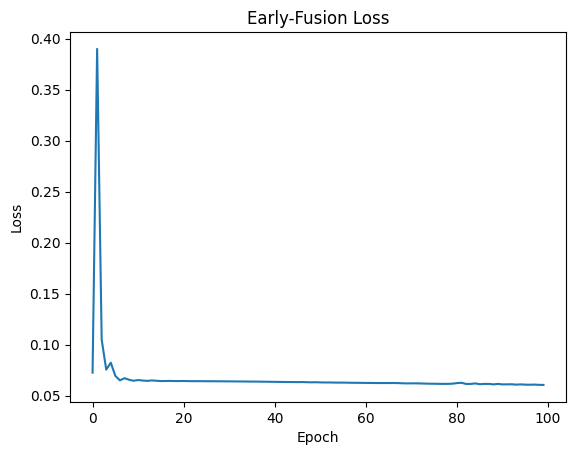

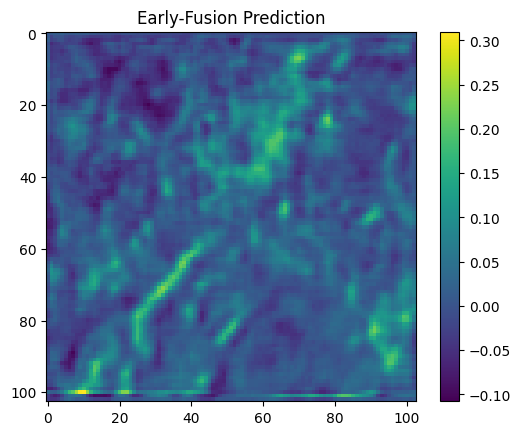

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0784
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 0.1912
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - loss: 0.0863
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.0674
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 0.0884
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 0.0912
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 0.0812
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 0.0711
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 0.0660
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 0.0645
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.0649
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - loss: 0.0654
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - loss: 0.0655
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - loss: 0.0655
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step - loss: 0.0654
Epoch 1

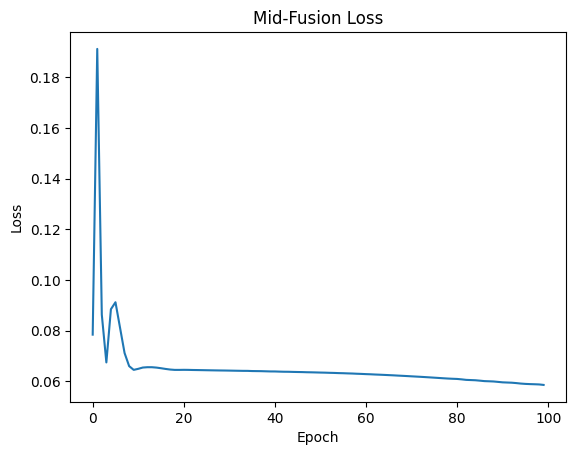

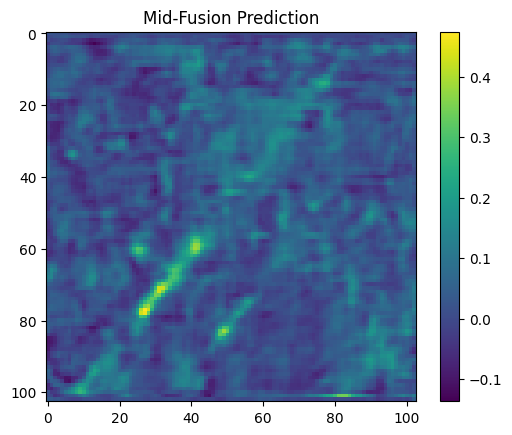

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1966
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.4769
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1254
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.3761
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.2390
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 0.1112
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - loss: 0.1967
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.2321
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1458
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0967
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.1420
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.1761
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.1391
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0968
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1103
Epoch 1

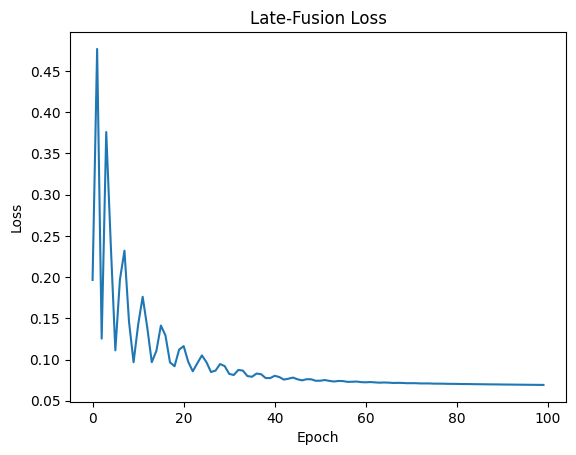

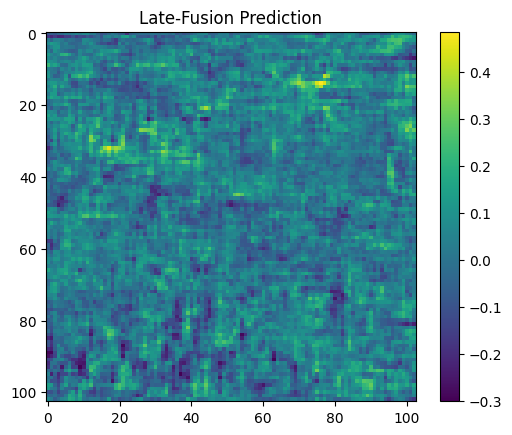

In [ ]:
# this block includes scaling acorss all avaiable bands

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# --- Load your training, testing, validation arrays ---
X_train = training
y_train = y_trainining
X_test = testing
y_test = y_testing
X_val = validation
y_val = y_validation

# -------------------------------
# Sanitize X and Y arrays
# -------------------------------
def sanitize_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr = np.clip(arr, -1e5, 1e5)
    return arr.astype(np.float32)

X_train = sanitize_array(X_train)
X_test = sanitize_array(X_test)
X_val = sanitize_array(X_val)
y_train = sanitize_array(y_train)
y_test = sanitize_array(y_test)
y_val = sanitize_array(y_val)

# -------------------------------
# Per-band MinMax scaling for X
# -------------------------------
def scale_per_band(X_train, X_test, X_val):
    n_bands = X_train.shape[-1]
    X_train_scaled = np.zeros_like(X_train)
    X_test_scaled = np.zeros_like(X_test)
    X_val_scaled = np.zeros_like(X_val)

    for i in range(n_bands):
        scaler = MinMaxScaler()
        train_band = X_train[:, :, i].reshape(-1, 1)
        test_band = X_test[:, :, i].reshape(-1, 1)
        val_band = X_val[:, :, i].reshape(-1, 1)

        scaler.fit(train_band)

        X_train_scaled[:, :, i] = scaler.transform(train_band).reshape(X_train.shape[0], X_train.shape[1])
        X_test_scaled[:, :, i] = scaler.transform(test_band).reshape(X_test.shape[0], X_test.shape[1])
        X_val_scaled[:, :, i] = scaler.transform(val_band).reshape(X_val.shape[0], X_val.shape[1])

    return X_train_scaled, X_test_scaled, X_val_scaled

X_train, X_test, X_val = scale_per_band(X_train, X_test, X_val)

# -------------------------------
# Pad X data to match output size
# -------------------------------
def pad_input(X):
    return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

X_train = pad_input(X_train)
X_test = pad_input(X_test)
X_val = pad_input(X_val)
y_train = np.expand_dims(y_train, axis=0)
y_test = np.expand_dims(y_test, axis=0)
y_val = np.expand_dims(y_val, axis=0)

# -------------------------------
# Split inputs for mid and late fusion
# -------------------------------
def split_inputs(X):
    SAR = X[:, :, :, 0:8]
    dem = X[:, :, :, 8:10]
    landsat = X[:, :, :, 10:33]
    sentinel_2 = X[:, :, :, 33:45]
    return SAR, dem, landsat, sentinel_2

# -------------------------------
# Model builders (same as before)
# -------------------------------
def build_early_fusion(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model(inputs, x)

def build_mid_fusion():
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        return x

    x1 = block(input_SAR)
    x2 = block(input_dem)
    x3 = block(input_landsat)
    x4 = block(input_sentinel_2)

    x = Concatenate()([x1, x2, x3, x4])
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

def build_late_fusion():
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = Cropping2D(((0, 0), (2, 2)))(x)
        return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

    y1 = block(input_SAR)
    y2 = block(input_dem)
    y3 = block(input_landsat)
    y4 = block(input_sentinel_2)

    y = Add()([y1, y2, y3, y4])
    y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)

# -------------------------------
# Compile and train models
# -------------------------------
def compile_and_train(model, X, y, name):
    model.compile(optimizer=Adam(), loss='mse')
    history = model.fit(X, y, epochs=100, verbose=1)
    y_pred = model.predict(X)

    mse = mean_squared_error(y.flatten(), y_pred.flatten())
    r2 = r2_score(y.flatten(), y_pred.flatten())
    print(f"{name}-fusion MSE: {mse:.4f}, R^2: {r2:.4f}")

    plt.plot(history.history['loss'])
    plt.title(f'{name}-Fusion Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
    plt.title(f'{name}-Fusion Prediction')
    plt.colorbar()
    plt.show()

# -------------------------------
# Train models
# -------------------------------
model_early = build_early_fusion((103, 107, 45))
compile_and_train(model_early, X_train, y_train, 'Early')

SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
model_mid = build_mid_fusion()
compile_and_train(model_mid, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

model_late = build_late_fusion()
compile_and_train(model_late, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Late')


Viz


----- Early Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Early MSE: 0.0607
Early RMSE: 0.2464
Early MAE: 0.0631
Early R²: 0.0572


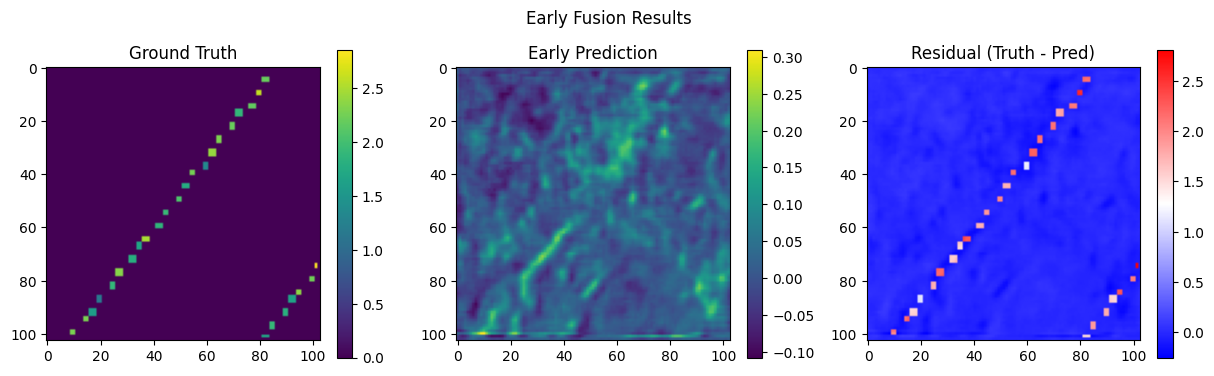


----- Mid Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Mid MSE: 0.0583
Mid RMSE: 0.2415
Mid MAE: 0.0737
Mid R²: 0.0940


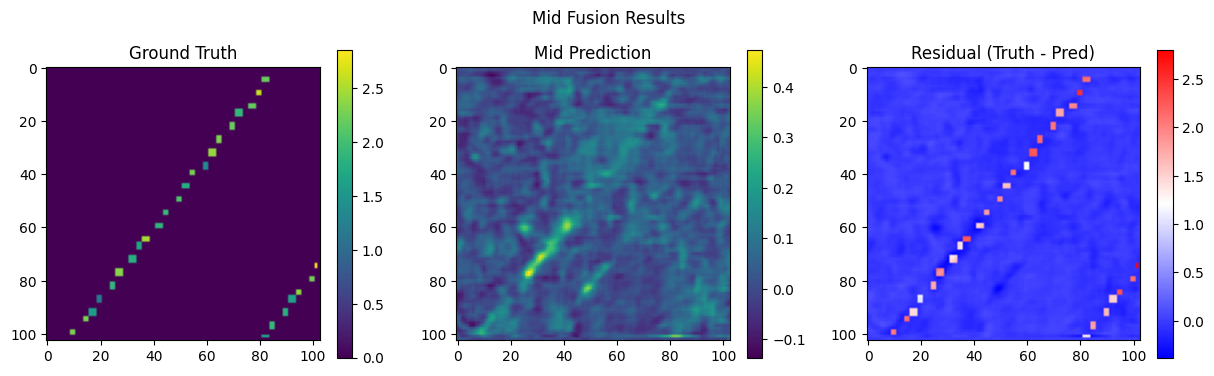


----- Late Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Late MSE: 0.0692
Late RMSE: 0.2630
Late MAE: 0.1017
Late R²: -0.0740


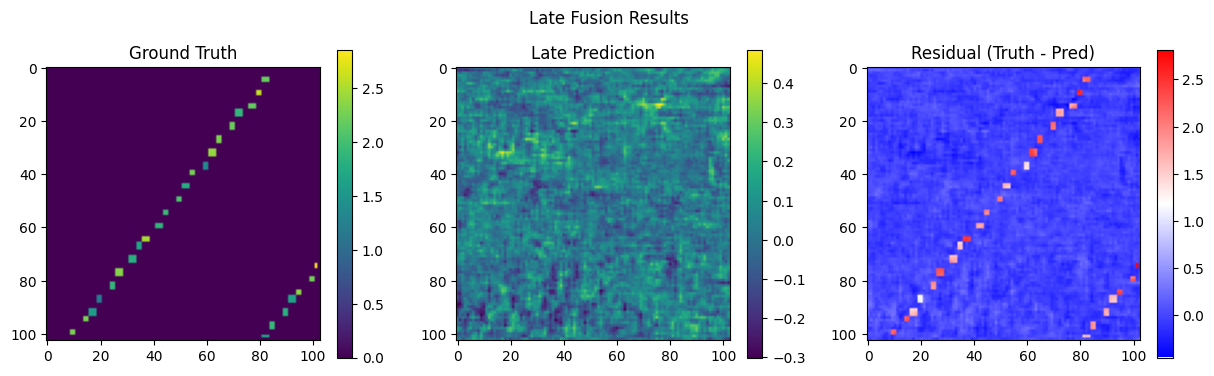

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def visualize_predictions(model, X_input, y_true, name):
    print(f"\n----- {name} Fusion Evaluation -----")

    # Predict
    y_pred = model.predict(X_input)

    # Flatten for stats
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Metrics
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)

    print(f"{name} MSE: {mse:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} MAE: {mae:.4f}")
    print(f"{name} R²: {r2:.4f}")

    # Visualize
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(y_true[0, :, :, 0], cmap='viridis')
    plt.title('Ground Truth')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
    plt.title(f'{name} Prediction')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow((y_true[0, :, :, 0] - y_pred[0, :, :, 0]), cmap='bwr')
    plt.title('Residual (Truth - Pred)')
    plt.colorbar()

    plt.suptitle(f'{name} Fusion Results')
    plt.show()

# --- Run for Early ---
visualize_predictions(model_early, X_test, y_test, 'Early')

# --- Run for Mid ---
SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
visualize_predictions(model_mid, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Mid')

# --- Run for Late ---
visualize_predictions(model_late, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Late')
